Epoch: 100, Loss: 57.6851
Epoch: 200, Loss: 34.7416
Epoch: 300, Loss: 21.1934
Epoch: 400, Loss: 12.6177
Epoch: 500, Loss: 7.8651
Epoch: 600, Loss: 5.3619
Epoch: 700, Loss: 3.9964
Epoch: 800, Loss: 3.0986
Epoch: 900, Loss: 2.4689
Epoch: 1000, Loss: 1.9978

True parameters: [2.0, -1.0, 0.5]
Learned parameters: [np.float32(-2.0472035), np.float32(1.3358579), np.float32(-2.1289759), np.float32(-1.8496017), np.float32(1.8401608), np.float32(1.9194385), np.float32(-1.8402495), np.float32(1.7967672), np.float32(2.169932), np.float32(-1.685401), np.float32(-5.2458973), np.float32(-3.1617112), np.float32(-2.8354743), np.float32(-0.6924838), np.float32(-5.3566947), np.float32(-2.2797797), np.float32(-0.8378089), np.float32(-2.1818757), np.float32(-1.5633031), np.float32(-2.7530549), np.float32(2.1254277), np.float32(1.938867), np.float32(1.1606315), np.float32(1.269881), np.float32(1.9375396), np.float32(1.3578249), np.float32(1.3239508), np.float32(1.1735511), np.float32(1.1269356), np.float32(

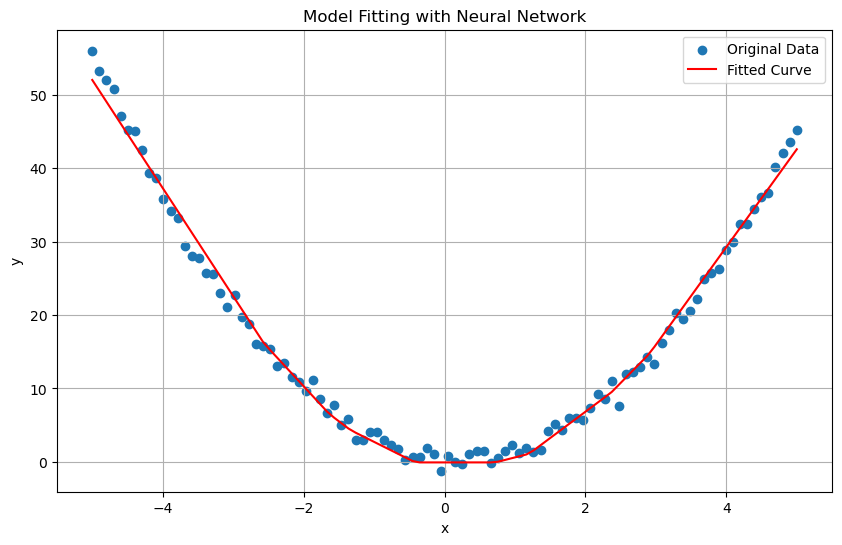

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# Define the neural network model
class ParameterFitter(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(ParameterFitter, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

# Generate synthetic data
np.random.seed(42)
true_params = [2.0, -1.0, 0.5] # Example parameters for a 2nd degree polynomial
x_data = np.linspace(-5, 5, 100)
y_data = true_params[0] * x_data**2 + true_params[1] * x_data + true_params[2] + np.random.normal(0, 1, 100)

# Convert data to tensors
x_tensor = torch.tensor(x_data, dtype=torch.float).unsqueeze(1) # Reshape to [100, 1]
y_tensor = torch.tensor(y_data, dtype=torch.float).unsqueeze(1) # Reshape to [100, 1]

# Model instantiation
input_size = 1
hidden_size = 10
output_size = 1
model = ParameterFitter(input_size, hidden_size, output_size)

# Loss and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Training loop
num_epochs = 1000
for epoch in range(num_epochs):
    # Forward pass
    y_predicted = model(x_tensor)
    loss = criterion(y_predicted, y_tensor)

    # Backward pass and optimization
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 100 == 0:
        print(f"Epoch: {epoch+1}, Loss: {loss.item():.4f}")

# Extract learned parameters
learned_params = []
for name, param in model.named_parameters():
    if param.requires_grad:
        if param.dim() == 1:  # Bias terms
            learned_params.extend(param.detach().numpy())
        else:  # Weight matrices
            learned_params.extend(param.detach().numpy().flatten())

print(f"\nTrue parameters: {true_params}")
print(f"Learned parameters: {learned_params}")

# Plotting
with torch.no_grad():
    y_predicted = model(x_tensor).numpy()

plt.figure(figsize=(10, 6))
plt.scatter(x_data, y_data, label='Original Data')
plt.plot(x_data, y_predicted, color='red', label='Fitted Curve')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Model Fitting with Neural Network')
plt.legend()
plt.grid(True)
plt.show()